<a href="https://colab.research.google.com/github/EmiiFernandez/actividades_data_sciente_ypf/blob/main/notebook/C06_Notebook-10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🤖 Guía de Asistencia con IA: IA como Copiloto de Programación

En esta notebook, utilizaremos la Inteligencia Artificial como copiloto de aprendizaje. Aquí tienes algunas sugerencias de cómo interactuar con un asistente de IA (como Gemini o ChatGPT):

- **Explicación de código**: Si encuentras una función o línea que no comprendes, pregúntale a la IA: *'Explica qué hace esta función línea por línea en Python: [pega tu código]'*.
- **Corrección de errores**: Si tienes un error al ejecutar, copia el error completo y pregúntale: *'¿Por qué este código genera este error y cómo lo soluciono? [pega tu código y error]'*.
- **Optimización**: Pregunta: *'¿Cómo puedo escribir este código de forma más eficiente y limpia?'*.


# Programa Ingenias+ Data Science




## Analisis Exploratorio de un Dataset

Esta notebook les permitiria ejercitar los conceptos de Pandas 🐼  y Análisis exploratorio de datos 📊 que aprendimos hasta ahora. Vamos a trabajar con un dataset que contiene datos relativos a [clientes de un centro comercial](https://www.kaggle.com/akram24/mall-customers). En el Drive esta descargado el archivo. Si tenes inconvenientes o  ese archivo no funciona podes descargarlo directamente de la página web.

### 🔬 Comenzando el proyecto 🎉

Es tu primer dia como Data Scientist. Tu primer proyecto consiste en hacer un análisis de datos sobre clientes de un centro comercial para luego hacer una predicción de ventas o un analisis de cluster. Antes que nada, debes inspeccionar y visualizar tu dataset para saber con que datos estas trabajando.

Como mencionamos durante la clase, una de las primeras cosas que debe realizar un Data Scientist al iniciar un nuevo proyecto es conocer el dataset con el cual va a trabajar. Este paso se conoce como _"Analisis exploratorio de los datos"_.

Además de obtener que tipo de datos contiene el dataset, estadistica descriptiva, detectar problemas como valores faltantes, establecer que tipo de relación existe entre las distintas variables, también debemos visualizar los datos. Este análisis nos permitira hacernos preguntas que puedan ser contestadas con el dataset como así plantear estrategias para poder resolver problemas presentes en él.

#### IMPORTA LAS LIBRERIAS NECESARIAS

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [87]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
data = pd.read_csv('/content/drive/MyDrive/Data Science - EnergIA/clientes_mall.csv')

**_Lee los datos que se encuentran en el archivo `clientes_mall.csv`. Guardalos en un DataFrame._**

In [89]:
data

,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,1.0,Male,19.0,15.0,39.0
1,1,2.0,NaN,21.0,15.0,81.0
2,2,3.0,Female,20.0,16.0,6.0
3,3,4.0,Female,23.0,16.0,77.0
4,4,5.0,NaN,31.0,17.0,40.0
...,...,...,...,...,...,...
195,195,196.0,NaN,35.0,120.0,79.0
196,196,197.0,Female,45.0,126.0,28.0
197,197,198.0,Male,32.0,126.0,74.0
198,198,199.0,Male,32.0,137.0,18.0


In [90]:
df = pd.DataFrame(data)

#### INSPECCIONA LOS DATOS

Primero obtene una visión general del dataset:


🤔 &nbsp; **_¿Como se ven las primeras 5 filas? ¿Cuantas filas y columnas posee? ¿Que tipos de datos contiene cada una de las columnas?_**

In [91]:
display(data.head(10))

,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,1.0,Male,19.0,15.0,39.0
1,1,2.0,NaN,21.0,15.0,81.0
2,2,3.0,Female,20.0,16.0,6.0
3,3,4.0,Female,23.0,16.0,77.0
4,4,5.0,NaN,31.0,17.0,40.0
5,5,6.0,Female,22.0,17.0,76.0
6,6,7.0,Female,35.0,NaN,6.0
7,7,8.0,Female,23.0,18.0,94.0
8,8,NaN,Male,64.0,19.0,NaN
9,9,10.0,Female,30.0,19.0,72.0


In [92]:
data.shape

(200, 6)

In [93]:
data.dtypes

,0
Unnamed: 0,int64
CustomerID,float64
Genre,object
Age,float64
Annual Income (k$),float64
Spending Score (1-100),float64


In [94]:
data

,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,1.0,Male,19.0,15.0,39.0
1,1,2.0,NaN,21.0,15.0,81.0
2,2,3.0,Female,20.0,16.0,6.0
3,3,4.0,Female,23.0,16.0,77.0
4,4,5.0,NaN,31.0,17.0,40.0
...,...,...,...,...,...,...
195,195,196.0,NaN,35.0,120.0,79.0
196,196,197.0,Female,45.0,126.0,28.0
197,197,198.0,Male,32.0,126.0,74.0
198,198,199.0,Male,32.0,137.0,18.0


In [95]:
data.dtypes


,0
Unnamed: 0,int64
CustomerID,float64
Genre,object
Age,float64
Annual Income (k$),float64
Spending Score (1-100),float64


In [96]:
data["Age"][(data["Age"] > 25) & (data["Age"] < 40)]

,Age
4,31.0
6,35.0
9,30.0
11,35.0
14,37.0
...,...
193,38.0
195,35.0
197,32.0
198,32.0


**_Hay algunas columnas que tienen nombres incomodos (ej. `Spending Score (1-100)` y `Annual Income (k$)`). Renombra esas columnas_**

In [97]:
data = data.rename(columns={'Spending Score (1-100)': 'Spending Score', 'Annual Income (k$)': 'Annual Income'})

#### Valores faltantes

🤔 &nbsp; **_¿Hay valores faltantes en alguna de las columnas?_**

In [98]:
data.isnull().sum()

,0
Unnamed: 0,0
CustomerID,11
Genre,14
Age,11
Annual Income,15
Spending Score,14


**_Elimina todas las filas que tengan valores faltantes_**

In [99]:
data = data.dropna()

#### FILTRA LOS DATOS

Porque tu compañia quiere diseñar un a campaña de marketing especial para personas entre 25 y 40 años, vamos a analizar los datos solo para estos clientes.

🤔 &nbsp; **_Chequea que categorias aparecen en la columna `Age`_**.

In [100]:
data['Age'].unique()

array([19., 20., 23., 22., 30., 67., 35., 58., 24., 37., 25., 31., 54.,
       29., 45., 40., 60., 49., 42., 36., 50., 27., 33., 59., 47., 53.,
       70., 63., 18., 68., 32., 26., 57., 38., 46., 21., 48., 34., 66.,
       65., 51., 43., 39., 44., 28., 41.])

**_Filtra los datos para quedarte unicamente con las filas que correspondan a personas entre 25 y 40 años. Guardalo en una variable que se llame `clientes_seleccionados`._**

In [101]:
clientes_seleccionados = data[(data['Age'] >= 25) & (data['Age'] <= 40)]

**_Reiniciamos el indice usando `reset_index()` para que las filas vuelvan a ser numeradas a partir de 0. `drop=True` permite descartar los indices anteriores y no guardarlos como una nueva columna. `inplace=True` permite que se modifique el DataFrame original._**

In [102]:
clientes_seleccionados.reset_index(drop=True, inplace=True)

**_Obtene estadistica descriptiva para las columnas que corresponden al salario anual y puntaje de gastos de las personas entre 25 y 40 años. Lo importante es que se muestre promedio, mediana, desvio estandard, valores minimos y maximos._**

🤔 &nbsp; De acuerdo a los valores **_¿Cuál es el sueldo promedio de estos clientes? ¿Cual es el puntaje de gastos mediano en el grupo? ¿Crees que son buenas medidas para caracterizar el grupo?_**

In [103]:
# Muestra estadísticas que incluyen promedio (mean), desvío (std), min, máx
display(clientes_seleccionados[['Annual Income', 'Spending Score']].describe())

# Muestra la mediana para ambas columnas
print("Mediana de Annual Income:", clientes_seleccionados['Annual Income'].median())
print("Mediana de Spending Score:", clientes_seleccionados['Spending Score'].median())

,Annual Income,Spending Score
count,61.00000,61.000000
mean,67.04918,56.639344
std,28.81286,28.287237
min,19.00000,1.000000
25%,43.00000,35.000000
50%,72.00000,58.000000
75%,81.00000,78.000000
max,137.00000,99.000000


Mediana de Annual Income: 72.0
Mediana de Spending Score: 58.0


**_Compara estos valores con aquellos de los clientes en general._**

In [104]:
# Muestra estadísticas del grupo general vs. el grupo de 25-40 años
print("--- Clientes en General ---")
display(data[['Annual Income', 'Spending Score']].describe())

print("--- Clientes de 25 a 40 años ---")
display(
    clientes_seleccionados[['Annual Income', 'Spending Score']].describe()
)

--- Clientes en General ---


,Annual Income,Spending Score
count,139.000000,139.000000
mean,60.762590,47.856115
std,26.636464,25.678492
min,15.000000,1.000000
25%,42.500000,28.000000
50%,61.000000,47.000000
75%,77.000000,67.500000
max,137.000000,99.000000


--- Clientes de 25 a 40 años ---


,Annual Income,Spending Score
count,61.00000,61.000000
mean,67.04918,56.639344
std,28.81286,28.287237
min,19.00000,1.000000
25%,43.00000,35.000000
50%,72.00000,58.000000
75%,81.00000,78.000000
max,137.00000,99.000000


**_Obtiene la edad promedio de clientes que tienen un sueldo mayor al promedio._**

In [105]:
sueldo_promedio = data['Annual Income'].mean()

In [106]:
clientes_sueldo_alto = data[data['Annual Income'] > sueldo_promedio]

**_Compara estos valores con aquellos de los clientes en general._**

In [107]:
edad_promedio_sueldo_alto = clientes_sueldo_alto['Age'].mean()
edad_promedio_general = data['Age'].mean()

print(f"Edad promedio de clientes con sueldo alto: {edad_promedio_sueldo_alto:.2f} años")
print(f"Edad promedio de todos los clientes: {edad_promedio_general:.2f} años")

Edad promedio de clientes con sueldo alto: 39.40 años
Edad promedio de todos los clientes: 39.65 años


### Visualización de la distribución de 'Annual Income' y 'Spending Score'

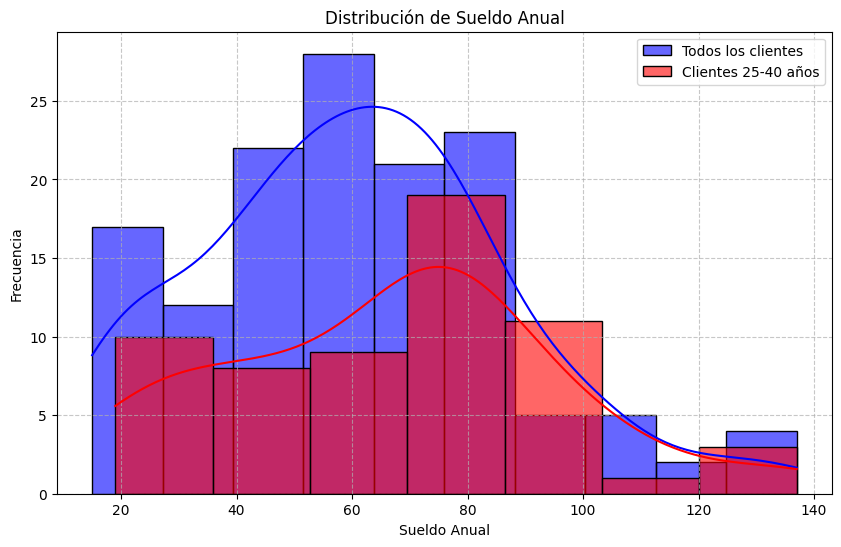

In [108]:
# Gráfico de distribución para 'Annual Income'
plt.figure(figsize=(10, 6))
sns.histplot(data['Annual Income'], kde=True, color='blue', label='Todos los clientes', alpha=0.6)
sns.histplot(clientes_seleccionados['Annual Income'], kde=True, color='red', label='Clientes 25-40 años', alpha=0.6)
plt.title('Distribución de Sueldo Anual')
plt.xlabel('Sueldo Anual')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

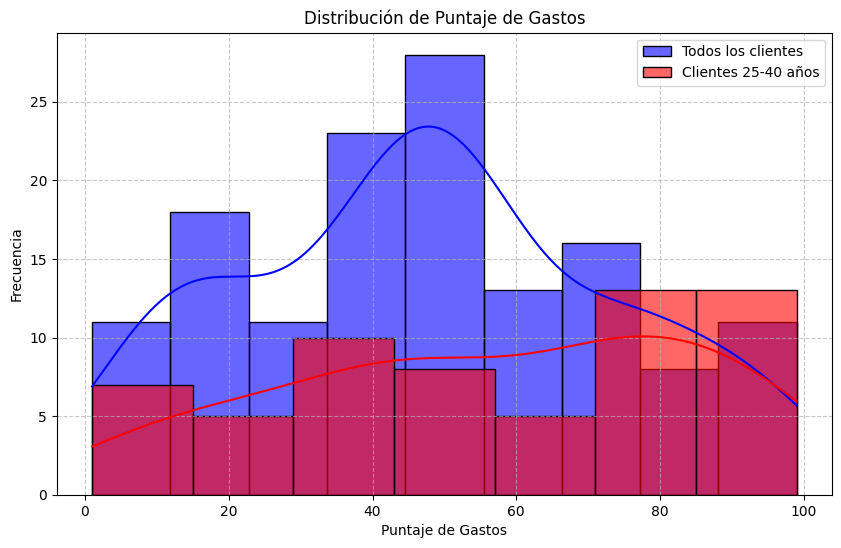

In [109]:
# Gráfico de distribución para 'Spending Score'
plt.figure(figsize=(10, 6))
sns.histplot(data['Spending Score'], kde=True, color='blue', label='Todos los clientes', alpha=0.6)
sns.histplot(clientes_seleccionados['Spending Score'], kde=True, color='red', label='Clientes 25-40 años', alpha=0.6)
plt.title('Distribución de Puntaje de Gastos')
plt.xlabel('Puntaje de Gastos')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

🤔 &nbsp; **_¿Qué otras preguntas te surgen para analizar en este dataset?_**

#### VISUALIZA LOS DATOS

**_Visualiza la distribución de las variables de sueldo promedio y puntaje de gastos. Haz gráficos que superpongan la distribución de cada una de estas variables de manera global como también sólo para los clientes seleccionados._**

### Visualización de la relación entre Edad y Puntaje de Gastos / Sueldo Anual

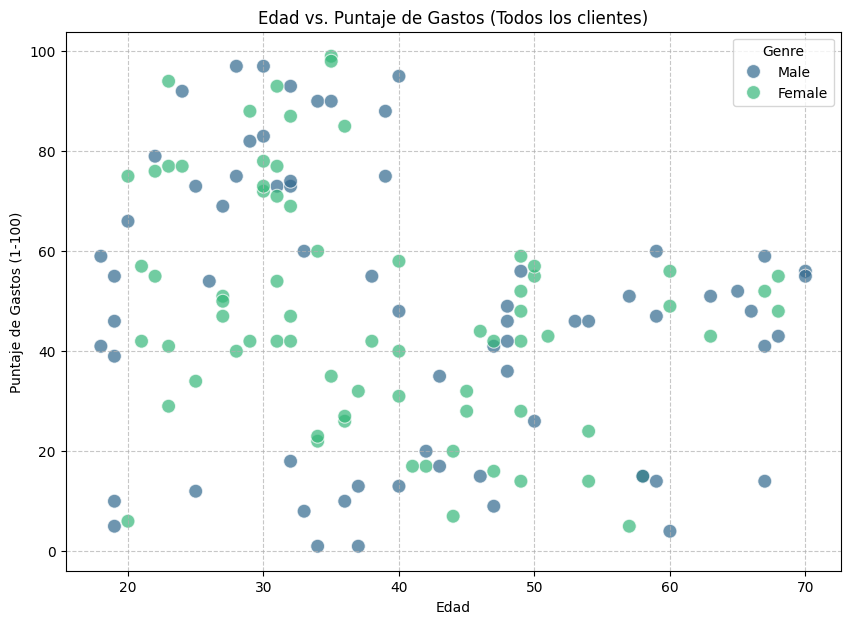

In [110]:
# Gráfico de dispersión para Edad vs. Puntaje de Gastos (Todos los clientes)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=data, x='Age', y='Spending Score', hue='Genre', palette='viridis', s=100, alpha=0.7)
plt.title('Edad vs. Puntaje de Gastos (Todos los clientes)')
plt.xlabel('Edad')
plt.ylabel('Puntaje de Gastos (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

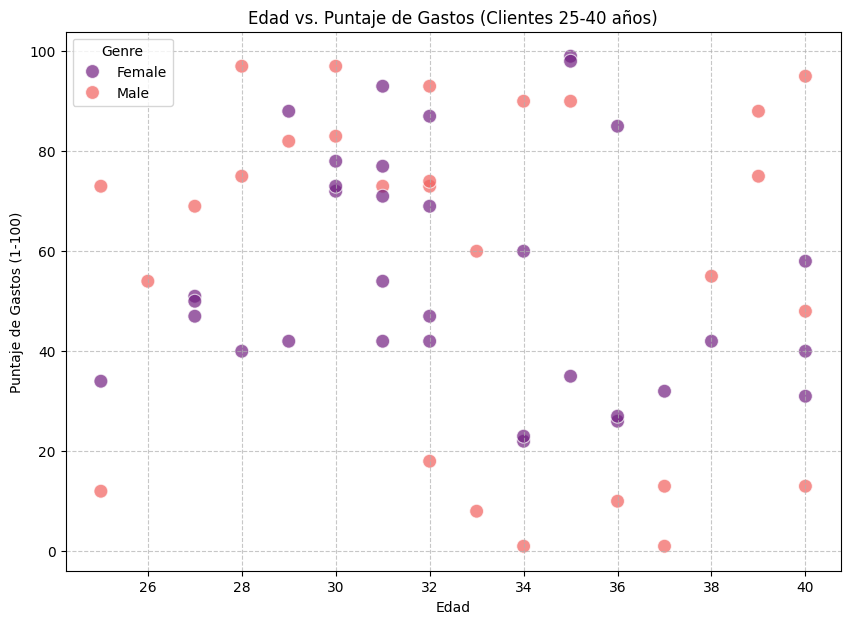

In [111]:
# Gráfico de dispersión para Edad vs. Puntaje de Gastos (Clientes 25-40 años)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=clientes_seleccionados, x='Age', y='Spending Score', hue='Genre', palette='magma', s=100, alpha=0.7)
plt.title('Edad vs. Puntaje de Gastos (Clientes 25-40 años)')
plt.xlabel('Edad')
plt.ylabel('Puntaje de Gastos (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

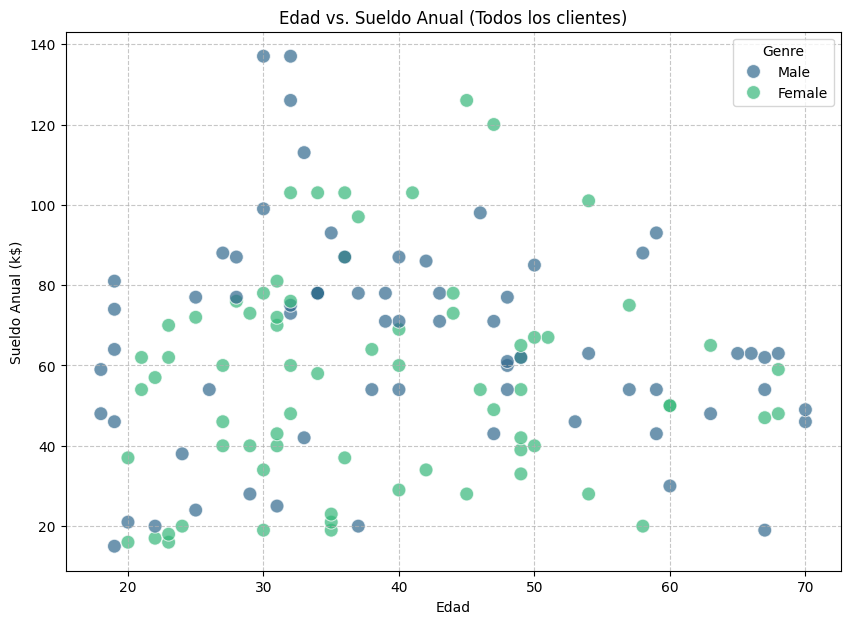

In [112]:
# Gráfico de dispersión para Edad vs. Sueldo Anual (Todos los clientes)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=data, x='Age', y='Annual Income', hue='Genre', palette='viridis', s=100, alpha=0.7)
plt.title('Edad vs. Sueldo Anual (Todos los clientes)')
plt.xlabel('Edad')
plt.ylabel('Sueldo Anual (k$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

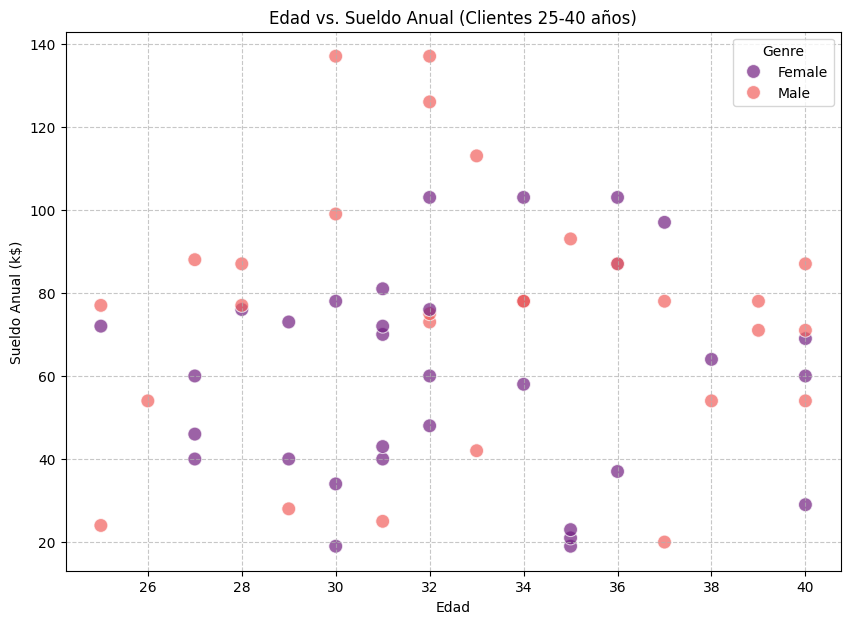

In [113]:
# Gráfico de dispersión para Edad vs. Sueldo Anual (Clientes 25-40 años)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=clientes_seleccionados, x='Age', y='Annual Income', hue='Genre', palette='magma', s=100, alpha=0.7)
plt.title('Edad vs. Sueldo Anual (Clientes 25-40 años)')
plt.xlabel('Edad')
plt.ylabel('Sueldo Anual (k$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**_Agrupa los datos por la variable `Genre` para ambos casos. Gráfica el ingreso promedio y su dispersion. Grafica, luego, el ingreso mediano y su rango intercuartil._**

Ingreso promedio y desviación estándar por género (Todos los clientes):


,Genre,mean,std
0,Female,56.736111,26.117822
1,Male,65.089552,26.701907



Ingreso promedio y desviación estándar por género (Clientes 25-40 años):


,Genre,mean,std
0,Female,59.969697,25.094179
1,Male,75.392857,31.065450


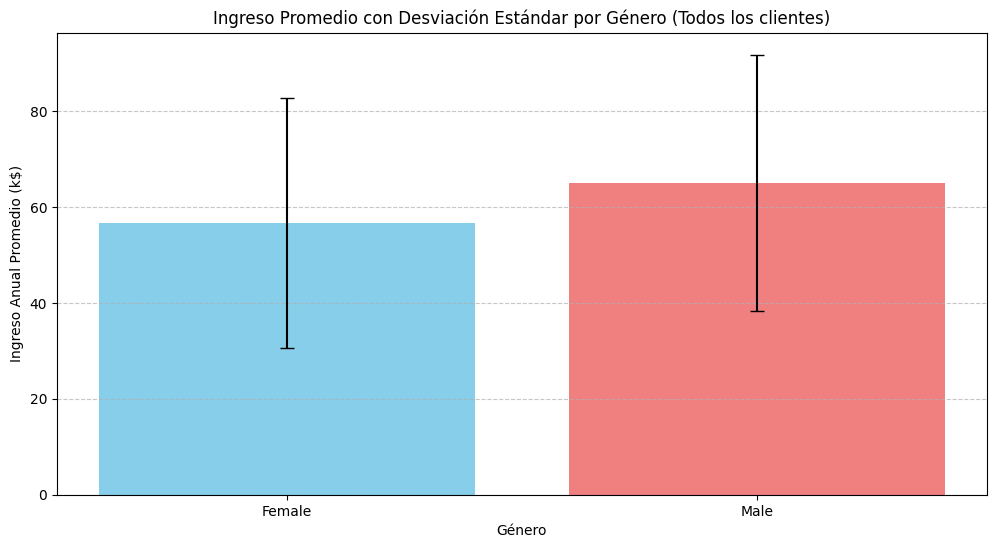

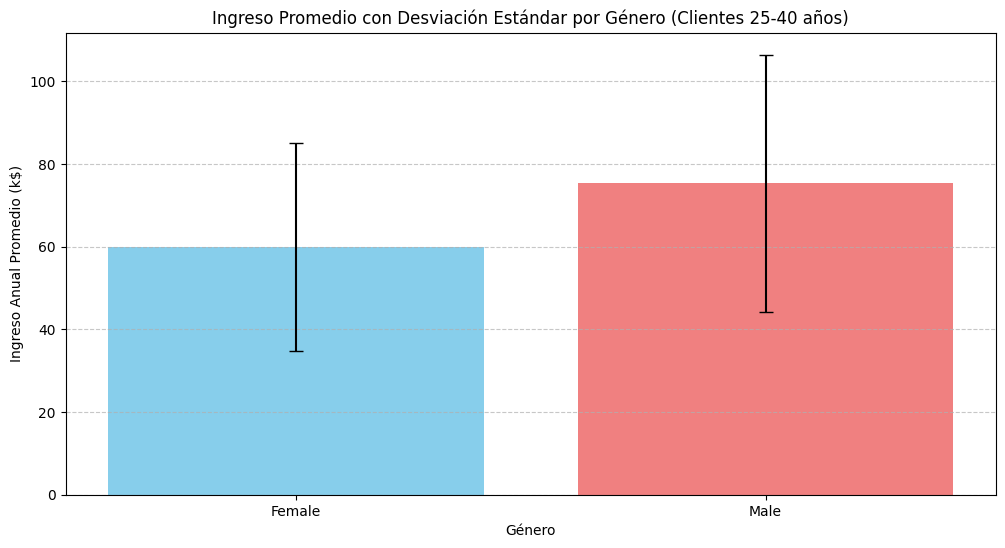

In [114]:
# Agrupar por género y calcular el ingreso promedio y la desviación estándar para todos los clientes
general_income_stats = data.groupby('Genre')['Annual Income'].agg(['mean', 'std']).reset_index()

# Agrupar por género y calcular el ingreso promedio y la desviación estándar para clientes seleccionados
selected_income_stats = clientes_seleccionados.groupby('Genre')['Annual Income'].agg(['mean', 'std']).reset_index()

print("Ingreso promedio y desviación estándar por género (Todos los clientes):")
display(general_income_stats)

print("\nIngreso promedio y desviación estándar por género (Clientes 25-40 años):")
display(selected_income_stats)

# Gráfico de barras para ingreso promedio y su dispersión (Todos los clientes)
plt.figure(figsize=(12, 6))
plt.bar(general_income_stats['Genre'], general_income_stats['mean'], yerr=general_income_stats['std'], capsize=5, color=['skyblue', 'lightcoral'])
plt.title('Ingreso Promedio con Desviación Estándar por Género (Todos los clientes)')
plt.xlabel('Género')
plt.ylabel('Ingreso Anual Promedio (k$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Gráfico de barras para ingreso promedio y su dispersión (Clientes 25-40 años)
plt.figure(figsize=(12, 6))
plt.bar(selected_income_stats['Genre'], selected_income_stats['mean'], yerr=selected_income_stats['std'], capsize=5, color=['skyblue', 'lightcoral'])
plt.title('Ingreso Promedio con Desviación Estándar por Género (Clientes 25-40 años)')
plt.xlabel('Género')
plt.ylabel('Ingreso Anual Promedio (k$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Mediana de ingreso por género (Todos los clientes):


,Genre,Annual Income
0,Female,57.5
1,Male,63.0



Mediana de ingreso por género (Clientes 25-40 años):


,Genre,Annual Income
0,Female,60.0
1,Male,77.5


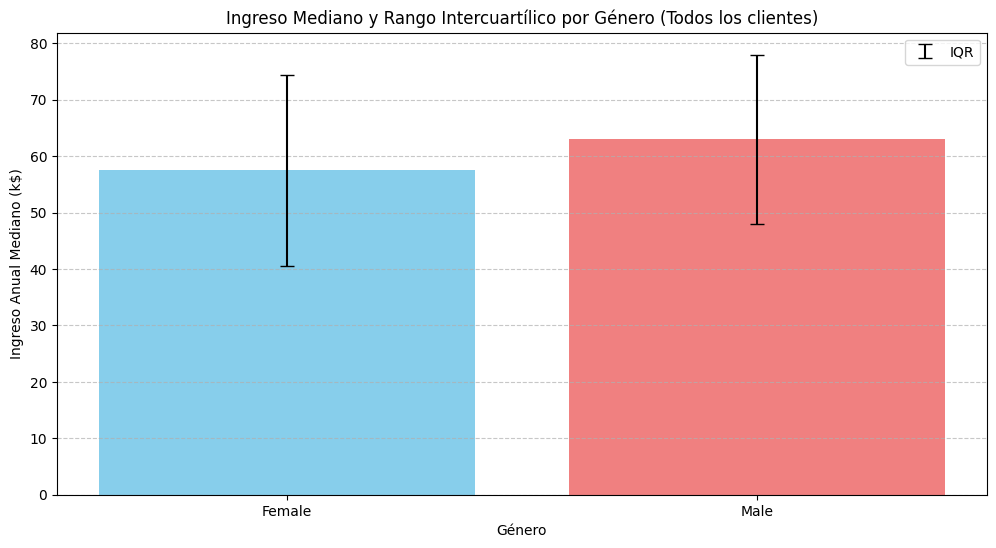

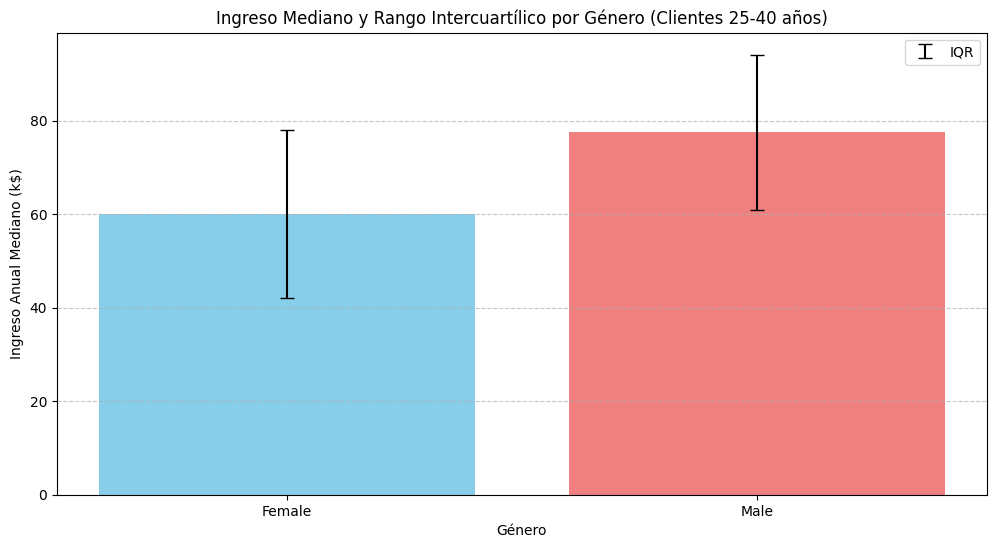

In [115]:
# Agrupar por género y calcular la mediana y el rango intercuartílico (IQR) para todos los clientes
general_median_income = data.groupby('Genre')['Annual Income'].median().reset_index()
general_q1 = data.groupby('Genre')['Annual Income'].quantile(0.25).reset_index()
general_q3 = data.groupby('Genre')['Annual Income'].quantile(0.75).reset_index()
general_iqr = general_q3['Annual Income'] - general_q1['Annual Income']

# Agrupar por género y calcular la mediana y el rango intercuartílico (IQR) para clientes seleccionados
selected_median_income = clientes_seleccionados.groupby('Genre')['Annual Income'].median().reset_index()
selected_q1 = clientes_seleccionados.groupby('Genre')['Annual Income'].quantile(0.25).reset_index()
selected_q3 = clientes_seleccionados.groupby('Genre')['Annual Income'].quantile(0.75).reset_index()
selected_iqr = selected_q3['Annual Income'] - selected_q1['Annual Income']

print("Mediana de ingreso por género (Todos los clientes):")
display(general_median_income)

print("\nMediana de ingreso por género (Clientes 25-40 años):")
display(selected_median_income)

# Gráfico de barras para ingreso mediano y rango intercuartílico (Todos los clientes)
plt.figure(figsize=(12, 6))
plt.bar(general_median_income['Genre'], general_median_income['Annual Income'], color=['skyblue', 'lightcoral'])
plt.errorbar(general_median_income['Genre'], general_median_income['Annual Income'], yerr=general_iqr/2, fmt='none', capsize=5, color='black', label='IQR')
plt.title('Ingreso Mediano y Rango Intercuartílico por Género (Todos los clientes)')
plt.xlabel('Género')
plt.ylabel('Ingreso Anual Mediano (k$)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Gráfico de barras para ingreso mediano y rango intercuartílico (Clientes 25-40 años)
plt.figure(figsize=(12, 6))
plt.bar(selected_median_income['Genre'], selected_median_income['Annual Income'], color=['skyblue', 'lightcoral'])
plt.errorbar(selected_median_income['Genre'], selected_median_income['Annual Income'], yerr=selected_iqr/2, fmt='none', capsize=5, color='black', label='IQR')
plt.title('Ingreso Mediano y Rango Intercuartílico por Género (Clientes 25-40 años)')
plt.xlabel('Género')
plt.ylabel('Ingreso Anual Mediano (k$)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

🤔 &nbsp; **_¿Existe una correlación entre el sueldo anual y el puntaje de gastos en los clientes seleccionados? ¿Y en todos los clientes en general?_**

In [116]:
correlacion_general = data['Annual Income'].corr(data['Spending Score'])
correlacion_seleccionados = clientes_seleccionados['Annual Income'].corr(clientes_seleccionados['Spending Score'])

print(f"Correlación entre Sueldo Anual y Puntaje de Gastos (Todos los clientes): {correlacion_general:.2f}")
print(f"Correlación entre Sueldo Anual y Puntaje de Gastos (Clientes 25-40 años): {correlacion_seleccionados:.2f}")

Correlación entre Sueldo Anual y Puntaje de Gastos (Todos los clientes): -0.14
Correlación entre Sueldo Anual y Puntaje de Gastos (Clientes 25-40 años): -0.05


**_Visualiza otros datos que creas relevantes para este analisis._**

#### 💾 &nbsp; GUARDANDO EL ARCHIVO PARA LOS SIGUIENTES PASOS

Los siguientes pasos que vamos a tomar implican la transformación de los datos presentes en el dataset para un correcto ajuste de un modelo a elección. Para no tener que correr nuevamente todo el código, podemos guardar en un archivo `csv` el dataset tal cual lo tenemos ahora.

1) **Utiliza la función `.to_csv()` para guardar tu dataset**. Antes de hacerlo chequea la [documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html).

In [117]:
data.to_csv('clientes_mall_final.csv', index=False)

In [118]:
# Para verificar que el archivo se guardó correctamente, carguémoslo en un nuevo DataFrame.
df_saved = pd.read_csv('clientes_mall_final.csv')
display(df_saved.head())

,Unnamed: 0,CustomerID,Genre,Age,Annual Income,Spending Score
0,0,1.0,Male,19.0,15.0,39.0
1,2,3.0,Female,20.0,16.0,6.0
2,3,4.0,Female,23.0,16.0,77.0
3,5,6.0,Female,22.0,17.0,76.0
4,7,8.0,Female,23.0,18.0,94.0
